# MASCOTS Counterfactual Explanations — FordA

This notebook demonstrates the **MASCOTS** (Model-Agnostic Symbolic COunterfactual explanations for Time Series) algorithm on the **FordA** dataset (univariate, binary classification) using the pretrained SimpleCNN model.

We compare three configurations:

| Variant | Key difference |
|---------|----------------|
| `mascots_scalar` | Our vendored port — `swap_method="scalar"`, `n_restarts=3` |
| `mascots_topk10` | Our vendored port — `swap_method="scalar"`, `select_top_k=10` — broader swap candidates |
| `mascots_original` | **Reference implementation** from the [ModelOriented/mascots](https://github.com/ModelOriented/mascots) GitHub repo (+ its `fast_borf` dependency from [DawidPludowski/borf](https://github.com/DawidPludowski/borf), `xai-improvements` branch), run as-is (only two scipy-compatibility one-liners patched — see the "Original MASCOTS baseline" section below) |

The goal of adding `mascots_original` is to sanity-check that `cfts/cf_mascots/mascots.py` (our self-contained, dependency-light reimplementation) tracks the authors' own code, not just the paper's description of the algorithm.

**References**
- Płudowski, D., Spinnato, F., Wilczyński, P., Kotowski, K., Ntagiou, E. V., Guidotti, R., & Biecek, P. (2025). *MASCOTS: Model-Agnostic Symbolic COunterfactual explanations for Time Series.* [arXiv:2503.22389](https://arxiv.org/html/2503.22389v1). ECML PKDD 2025.
- Original code: https://github.com/ModelOriented/mascots (BoRF engine: https://github.com/DawidPludowski/borf)

**Caveat on the baseline comparison:** the MASCOTS paper's own benchmark suite does *not* include FordA — it evaluates on TwoLeadECG, GunPoint, Earthquakes, Coffee, Wine, ItalyPowerDemand (univariate) and BasicMotions, Cricket, Epilepsy, RacketSports (multivariate), against M-CELS and Glacier baselines. So the numbers produced here are *not* directly comparable to the paper's Table 2 — this notebook instead uses FordA (already used elsewhere in this repo) purely to check that our reimplementation and the authors' original code behave similarly on the same model/data. Paper-reported numbers are summarized as context in a later markdown cell, not reproduced.</cell_type>


In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_mascots import mascots_cf
from cfts.metrics import (
    autocorrelation_preservation,
    dtw_distance,
    evaluate_keane_metrics,
    feature_range_validity,
    l2_distance,
    normalized_distance,
    percentage_changed_points,
    prediction_change,
)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    """Return raw logits as (n_classes,) numpy array."""
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        ts = ts.reshape(1, ts.shape[0], ts.shape[1]) if ts.shape[0] <= ts.shape[1] else ts.T.unsqueeze(0)
    elif ts.ndim == 3:
        if ts.shape[0] != 1:
            ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    if arr.ndim == 3:
        return arr[0]
    raise ValueError(f"Unsupported shape: {arr.shape}")


# Evaluate model on test set
y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth


Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9220


In [3]:
# Build background / training data for the BorfExplainer surrogate
# mascots_cf expects `dataset` as a sequence of (x, y) pairs or an (N, C, L) array

BG_SIZE = min(300, len(dataset_train))

X_bg = np.stack(
    [np.asarray(dataset_train[i][0], dtype=np.float32) for i in range(BG_SIZE)], axis=0
)  # (N, 1, L)
y_bg_onehot = np.stack(
    [np.asarray(dataset_train[i][1], dtype=np.float32) for i in range(BG_SIZE)], axis=0
)  # (N, n_classes)
y_bg_int = np.argmax(y_bg_onehot, axis=1)  # (N,)

# mascots_cf accepts list-of-(x,y) pairs
background_dataset = list(zip(X_bg, y_bg_int))

# Reference data for feature_range_validity metric
reference_data = X_bg

print(f"Background data: {X_bg.shape}, labels: {y_bg_int.shape}")
print(f"Label distribution: {np.unique(y_bg_int, return_counts=True)}")

Background data: (300, 1, 500), labels: (300,)
Label distribution: (array([0, 1]), array([157, 143]))


## Original MASCOTS baseline (ModelOriented/mascots)

To use the authors' own code as a baseline, we clone it into a **gitignored** directory (`cfts/cf_mascots/external/`, matched by the `**/external/` rule in `.gitignore`) rather than vendoring it into the repo:

```bash
mkdir -p cfts/cf_mascots/external
git clone https://github.com/ModelOriented/mascots.git cfts/cf_mascots/external/mascots_github
# mascots' own BorfExplainer needs the fast_borf package, which is not on PyPI —
# it lives in a companion repo the authors clone as part of their own setup script
# (cfts/cf_mascots/external/mascots_github/scripts/setup_env.sh):
git clone https://github.com/DawidPludowski/borf.git cfts/cf_mascots/external/borf_github
cd cfts/cf_mascots/external/borf_github && git checkout xai-improvements && pip install -e .
```

Extra (standard, PyPI) dependencies installed into the project venv: `loguru`, `pytorch_lightning`, `shap`, `gpytorch`.

**Patches applied to the cloned code** (both are 1-line scipy compatibility fixes — the repo pins `scipy==1.15.0` in its conda env, but newer `scipy.sparse` arrays no longer allow scalar column indexing like `X[:, i]`; we use `X[:, [i]]` instead — no algorithmic change):
- `external/borf_github/fast_borf/xai/mapping.py`: `X_transformed[:, feature]` → `X_transformed[:, [feature]]`
- `external/mascots_github/mascots/explainer/borf.py`: `X_transformed[0, :]` → `X_transformed[[0], :]`

If `cfts/cf_mascots/external/mascots_github` isn't present, the cells below skip the `mascots_original` baseline gracefully and the rest of the notebook still runs with the two vendored variants.

**Hyperparameters used below mirror the paper's own experiment defaults**, taken directly from `experiments/bin/create_borf_cf.py` + `bin/utils/configs.py` (`default_borf_explainer_*_args`), not just the paper text:
- `borf_config` = `mascots.explainer.pipeline.get_borf_config(X_train.shape)` (auto window/word sizes; the script overrides the `config/126_borf_full.json` default with this)
- `attribution_name="shap"`, `attribution_args={"mode": "deep"}` — SHAP **DeepExplainer** on the MLP surrogate (the actual experiment default, not the plain `Explainer`/Permutation fallback)
- `swap_method="scalar"`, `max_borf_changes=20`, `select_top_k=5`, `C=0.1` (the script's `C` env-var default), `n_restarts=1` (their `N_COUNTERFACTUALS=1`)

In [4]:
EXTERNAL_MASCOTS_DIR = REPO_ROOT / "cfts" / "cf_mascots" / "external" / "mascots_github"
EXTERNAL_BORF_DIR = REPO_ROOT / "cfts" / "cf_mascots" / "external" / "borf_github"

HAVE_ORIGINAL_MASCOTS = EXTERNAL_MASCOTS_DIR.exists()

if HAVE_ORIGINAL_MASCOTS:
    sys.path.insert(0, str(EXTERNAL_MASCOTS_DIR))
    try:
        from mascots.explainer.borf import BorfExplainer as OriginalBorfExplainer
        from mascots.explainer.pipeline import get_borf_config as original_get_borf_config
        print(f"Loaded original MASCOTS implementation from {EXTERNAL_MASCOTS_DIR}")
    except ImportError as exc:
        HAVE_ORIGINAL_MASCOTS = False
        print(f"Found {EXTERNAL_MASCOTS_DIR} but failed to import mascots/fast_borf ({exc}).")
        print("Install: loguru, pytorch_lightning, shap, gpytorch, and `pip install -e` the borf_github clone.")
else:
    print(
        f"{EXTERNAL_MASCOTS_DIR} not found — skipping the mascots_original baseline.\n"
        "See the markdown cell above for the clone/patch/install steps."
    )

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Loaded original MASCOTS implementation from /workspaces/counterfactual-explanations-for-time-series/cfts/cf_mascots/external/mascots_github


In [5]:
def predict_proba_original(Xb: np.ndarray) -> np.ndarray:
    """(N, C, L) float64 -> (N, n_classes) softmax probabilities, for the original BorfExplainer."""
    ts = torch.tensor(np.asarray(Xb, dtype=np.float32), device=device)
    with torch.no_grad():
        return torch.softmax(model(ts), dim=1).cpu().numpy()


def predict_fn_original(Xb: np.ndarray) -> np.ndarray:
    return np.argmax(predict_proba_original(Xb), axis=1)


if HAVE_ORIGINAL_MASCOTS:
    X_bg_f64 = X_bg.astype(np.float64)  # original repo's BorfExplainer expects float64
    # borf_config via get_borf_config(...) matches what experiments/bin/create_borf_cf.py does
    # (it overrides the "config/126_borf_full.json" default with this auto-derived config).
    original_borf_config = original_get_borf_config(X_bg_f64.shape)
    print(f"original BoRF config: {len(original_borf_config)} window/word settings")

    t0 = time.time()
    original_explainer = OriginalBorfExplainer(
        predict_fn_original, predict_proba_original, borf_config=original_borf_config
    )
    # attribution_args={"mode": "deep"} matches bin/utils/configs.py's
    # default_borf_explainer_build_args (SHAP DeepExplainer instead of the plain
    # Permutation-based default) — this is the config the paper's own experiment
    # scripts actually run with, and it is ~9x faster per counterfactual call too.
    original_build_metrics = original_explainer.build(
        X_bg_f64,
        on_top_model=None,
        attribution_name="shap",
        attribution_args=dict(mode="deep"),
        n_folds=2,
        seed=42,
    )
    print(f"Original BorfExplainer.build() took {time.time() - t0:.1f}s")
    print(f"Surrogate metrics: {original_build_metrics}")

2026-07-15 13:56:35.646 | INFO     | mascots.explainer.borf:__init__:47 - Borf #configs: 6


2026-07-15 13:56:35.647 | INFO     | mascots.explainer.borf:__init__:48 - Borf #configs: [{'window_size': 8, 'stride': 1, 'dilation': 1, 'word_length': 4, 'alphabet_size': 3}, {'window_size': 16, 'stride': 1, 'dilation': 1, 'word_length': 4, 'alphabet_size': 3}, {'window_size': 32, 'stride': 1, 'dilation': 1, 'word_length': 4, 'alphabet_size': 3}, {'window_size': 64, 'stride': 1, 'dilation': 1, 'word_length': 4, 'alphabet_size': 3}, {'window_size': 128, 'stride': 1, 'dilation': 1, 'word_length': 4, 'alphabet_size': 3}, {'window_size': 256, 'stride': 1, 'dilation': 1, 'word_length': 4, 'alphabet_size': 3}]


original BoRF config: 6 window/word settings


(300, 1, 500)
<class 'numpy.ndarray'>


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1


...

Trainable params: 122 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 122 K                                                                                                
Total estimated model params size (MB): 0.488                                                                      
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.1


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


2026-07-15 13:57:38.206 | INFO     | mascots.explainer.borf:_map_borf_features:259 - create inner representation


Original BorfExplainer.build() took 62.6s
Surrogate metrics: {'accuracy': np.float64(0.8833333333333333), 'cross-entropy': np.float32(-0.3397198), 'mse': np.float32(0.03227348), 'r2': 0.3920166492462158}


Sample shape : (1, 500)
True label   : 0
Predicted    : 0  (scores: [9.9999988e-01 1.6135729e-07])
[mascots_cf] building BorfExplainer on N=300 samples …


[mascots_cf] surrogate metrics: {'accuracy': np.float64(0.96)}


[mascots_cf] done – original=0  cf=0  p_target=0.376

CF predicted : 0  (scores: [0.75269485 0.24730512])
CF shape     : (1, 500)


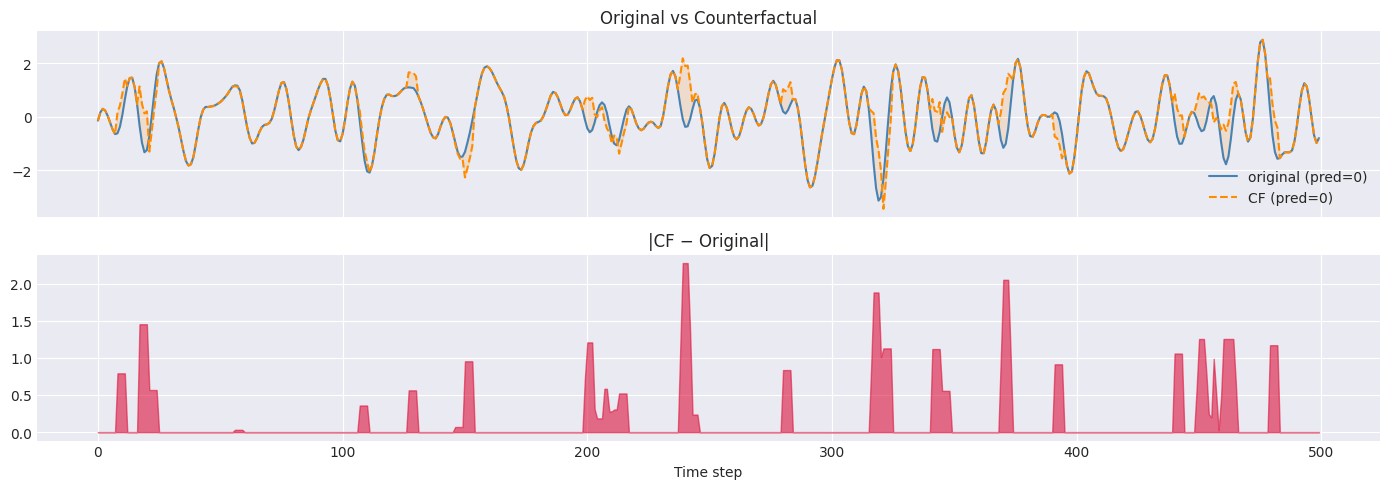

In [6]:
# --- Quick single-sample walkthrough ---
sample_raw, label_raw = dataset_test[0]
sample_raw = np.asarray(sample_raw, dtype=np.float32)
scores_orig = predict_scores(model, sample_raw, device)
pred_orig = int(np.argmax(scores_orig))
true_label = to_class_index(label_raw)

print(f"Sample shape : {sample_raw.shape}")
print(f"True label   : {true_label}")
print(f"Predicted    : {pred_orig}  (scores: {scores_orig})")

cf, cf_scores = mascots_cf(
    sample=sample_raw,
    model=model,
    dataset=background_dataset,
    max_iter=100,
    swap_method="scalar",
    n_restarts=3,
    C=0.1,
    select_top_k=5,
    seed=42,
    verbose=True,
)

cf_pred = int(np.argmax(cf_scores))
print(f"\nCF predicted : {cf_pred}  (scores: {cf_scores})")
print(f"CF shape     : {np.asarray(cf).shape}")

# Quick plot
x_1d = to_channel_first(sample_raw)[0]
cf_1d = to_channel_first(cf)[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(x_1d, color="steelblue", linewidth=1.5, label=f"original (pred={pred_orig})")
axes[0].plot(cf_1d, color="darkorange", linewidth=1.5, linestyle="--", label=f"CF (pred={cf_pred})")
axes[0].fill_between(np.arange(len(x_1d)), x_1d, cf_1d, alpha=0.15, color="darkorange")
axes[0].set_title("Original vs Counterfactual")
axes[0].legend()
axes[1].fill_between(np.arange(len(x_1d)), 0, np.abs(cf_1d - x_1d), color="crimson", alpha=0.6)
axes[1].set_title("|CF − Original|")
axes[1].set_xlabel("Time step")
plt.tight_layout()
plt.show()

In [7]:
def model_wrapper(ts: np.ndarray) -> np.ndarray:
    """(N, L) or (C, L) → scores array, for metrics helpers."""
    return predict_scores(model, np.asarray(ts, dtype=np.float32), device)


def infer_target_class(scores: np.ndarray) -> int:
    return int(np.argsort(scores)[::-1][1])


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


def compute_metrics(sample_cf, cf_cf, target_class):
    """Quality metrics for (sample, counterfactual) both as (C, L) arrays."""
    keane = evaluate_keane_metrics(
        original_ts_list=sample_cf,
        counterfactual_ts_list=cf_cf,
        model=model_wrapper,
        target_classes=int(target_class),
    )
    return {
        "l2_norm": float(l2_distance(sample_cf, cf_cf)),
        "dtw_proximity": float(dtw_distance(sample_cf, cf_cf)),
        "normalized_distance": float(normalized_distance(sample_cf.reshape(-1), cf_cf.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_cf, cf_cf)),
        "range_validity": float(feature_range_validity(cf_cf, reference_data)),
        "autocorr": float(autocorrelation_preservation(sample_cf, cf_cf)),
        "keane_validity": float(keane["validity"]),
        "keane_proximity": float(keane["proximity"]),
        "keane_compactness": float(keane["compactness"]),
        "validity": float(prediction_change(sample_cf, cf_cf, model_wrapper, target_class=target_class)),
    }

In [8]:
N_SAMPLES = 12  # kept modest: mascots_original rebuilds nothing per-call, but mascots_scalar/topk10
# each rebuild a fresh BoRF surrogate per sample (~40s) inside mascots_cf, and mascots_original's
# SHAP attribution.explain() is called at every swap step (~19s/sample) -> ~100s/sample x 3 methods

selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 12 correctly classified test samples.


In [9]:
METHODS = ["mascots_scalar", "mascots_topk10"]
METHOD_COLORS = ["#2a9d8f", "#264653"]

if HAVE_ORIGINAL_MASCOTS:
    METHODS.append("mascots_original")
    METHOD_COLORS.append("#e76f51")

# Paper (arXiv:2503.22389) defaults: max_borf_changes=20, C (their lambda) in {0.0, 0.1}, SHAP attribution.
ORIGINAL_MAX_BORF_CHANGES = 20
ORIGINAL_N_RESTARTS = 1  # kept at 1 for runtime (SHAP explain() is called every swap step); other variants use 3


def run_mascots(sample_raw, target_class, variant: str):
    if variant == "mascots_original":
        x_cl = to_channel_first(sample_raw).astype(np.float64)
        X_obs = x_cl[np.newaxis, ...]  # (1, C, L)
        cfs = original_explainer.counterfactual(
            X_obs,
            target_cls=target_class,
            swap_method="scalar",
            max_borf_changes=ORIGINAL_MAX_BORF_CHANGES,
            select_top_k=5,
            C=0.1,
            n_restarts=ORIGINAL_N_RESTARTS,
            returns_meta=False,
            seed=42,
        )
        cf = cfs[0].astype(np.float32)  # (C, L)
        scores = predict_proba_original(cf[np.newaxis, ...])[0]
        return cf, scores

    kwargs = dict(
        sample=sample_raw,
        model=model,
        target_class=target_class,
        dataset=background_dataset,
        max_iter=100,
        swap_method="scalar",
        C=0.1,
        attribution_name="coef",
        seed=42,
        verbose=False,
    )
    if variant == "mascots_scalar":
        kwargs.update(n_restarts=3, select_top_k=5)
    elif variant == "mascots_topk10":
        kwargs.update(n_restarts=3, select_top_k=10)
    else:
        raise ValueError(f"Unknown variant: {variant}")

    cf, scores = mascots_cf(**kwargs)
    return cf, scores

In [10]:
records = []
all_cfs = {}  # {sample_idx: {method: cf_array}}

for i, idx in enumerate(selected_indices):
    sample_raw, label = dataset_test[idx]
    sample_raw = np.asarray(sample_raw, dtype=np.float32)
    scores_orig = predict_scores(model, sample_raw, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = infer_target_class(scores_orig)

    all_cfs[idx] = {"sample": sample_raw, "true_label": true_label, "target_class": target_class}

    base = {
        "sample_idx": idx,
        "true_label": true_label,
        "pred_orig": pred_orig,
        "target_class": target_class,
    }

    for variant in METHODS:
        try:
            cf, cf_scores = run_mascots(sample_raw, target_class, variant)
            cf = np.asarray(cf, dtype=np.float32)
            cf_scores = np.asarray(cf_scores).reshape(-1)
            pred_cf = int(np.argmax(cf_scores))
            success = pred_cf == target_class
            sample_cl = to_channel_first(sample_raw)
            cf_cl = to_channel_first(cf)
            metrics = compute_metrics(sample_cl, cf_cl, target_class)
            records.append({
                **base, "method": variant,
                "pred_cf": pred_cf, "success": bool(success),
                **metrics, "error": None,
            })
            all_cfs[idx][variant] = cf
        except Exception as exc:
            records.append({
                **base, "method": variant,
                "pred_cf": None, "success": False, "error": f"{type(exc).__name__}: {exc}",
            })

    print(f"[{i + 1}/{len(selected_indices)}] Completed sample {idx}")

results_df = pd.DataFrame(records)
print(f"Evaluation complete. Total records: {len(results_df)}")
results_df.head(9)

2026-07-15 13:59:37.002 | WARNING  | mascots.explainer.borf:counterfactual:228 - Cnt not created after 19 iterations (inluding 15 failed)


[1/12] Completed sample 0


2026-07-15 14:00:52.018 | WARNING  | mascots.explainer.borf:counterfactual:228 - Cnt not created after 19 iterations (inluding 19 failed)


[2/12] Completed sample 1


2026-07-15 14:01:14.052 | INFO     | mascots.explainer.borf:counterfactual:222 - Success after 5 iterations (inluding 1 failed)


...

2026-07-15 14:07:33.780 | WARNING  | mascots.explainer.borf:counterfactual:228 - Cnt not created after 19 iterations (inluding 10 failed)


[11/12] Completed sample 11


2026-07-15 14:08:47.247 | WARNING  | mascots.explainer.borf:counterfactual:228 - Cnt not created after 19 iterations (inluding 11 failed)


[12/12] Completed sample 12
Evaluation complete. Total records: 36


,sample_idx,true_label,pred_orig,target_class,method,pred_cf,success,l2_norm,dtw_proximity,normalized_distance,sparsity,range_validity,autocorr,keane_validity,keane_proximity,keane_compactness,validity,error
0,0,0,0,1,mascots_scalar,0,False,10.668354,4.489332,0.079201,0.774,0.952,0.974751,0.0,10.668354,0.774,0.0,None
1,0,0,0,1,mascots_topk10,0,False,12.793571,6.337257,0.094979,0.640,0.942,0.974984,0.0,12.793571,0.646,0.0,None
2,0,0,0,1,mascots_original,0,False,5.399503,2.131400,0.040086,0.960,0.956,0.999883,0.0,5.399503,0.960,0.0,None
3,1,0,0,1,mascots_scalar,0,False,0.000000,0.000000,0.000000,1.000,0.962,1.000000,0.0,0.000000,1.000,0.0,None
4,1,0,0,1,mascots_topk10,0,False,0.000000,0.000000,0.000000,1.000,0.962,1.000000,0.0,0.000000,1.000,0.0,None
5,1,0,0,1,mascots_original,0,False,0.000000,0.000000,0.000000,1.000,0.962,1.000000,0.0,0.000000,1.000,0.0,None
6,2,0,0,1,mascots_scalar,1,True,4.831085,2.454369,0.024963,0.866,0.936,0.999986,1.0,4.831085,0.866,1.0,None
7,2,0,0,1,mascots_topk10,1,True,4.357328,2.127957,0.022515,0.868,0.936,0.999984,1.0,4.357328,0.868,1.0,None
8,2,0,0,1,mascots_original,1,True,2.700949,1.618750,0.013956,0.840,0.930,1.000000,1.0,2.700949,0.840,1.0,None


In [11]:
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        validity_mean=("validity", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            normalized_distance_mean=("normalized_distance", "mean"),
            sparsity_mean=("sparsity", "mean"),
            range_validity_mean=("range_validity", "mean"),
            autocorr_mean=("autocorr", "mean"),
            keane_proximity_mean=("keane_proximity", "mean"),
            keane_compactness_mean=("keane_compactness", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)
summary_df["n_successful"] = summary_df["n_successful"].fillna(0).astype(int)

display_cols = [
    "method", "n_successful", "success_rate", "validity_mean",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "range_validity_mean", "autocorr_mean",
    "keane_proximity_mean", "keane_compactness_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,validity_mean,l2_norm_mean,dtw_proximity_mean,sparsity_mean,range_validity_mean,autocorr_mean,keane_proximity_mean,keane_compactness_mean
0,mascots_original,1,8.3,0.0833,2.7009,1.6188,0.8400,0.9300,1.0000,2.7009,0.8400
1,mascots_scalar,7,58.3,0.5833,15.3550,8.2023,0.6149,0.9043,0.9983,15.3550,0.6151
2,mascots_topk10,9,75.0,0.7500,11.9449,6.2283,0.6342,0.9207,0.9982,11.9449,0.6351


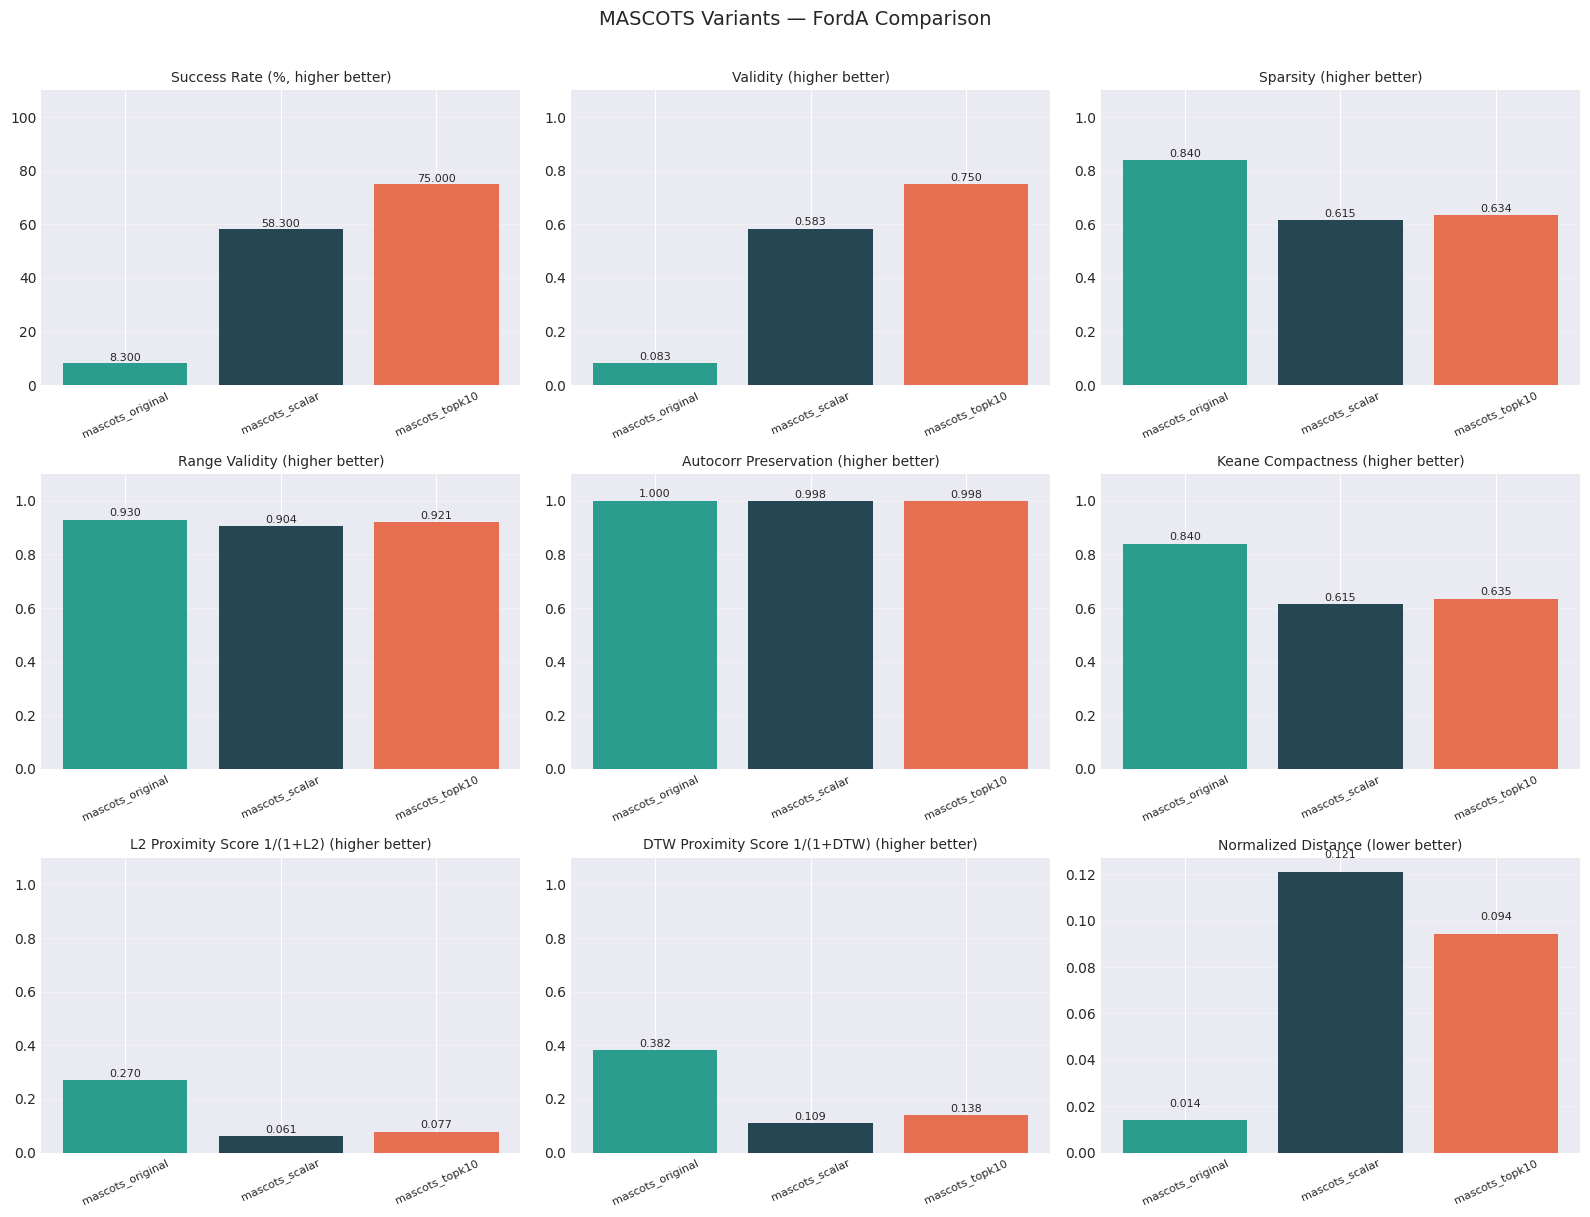

In [12]:
plot_df = summary_df.sort_values("method").reset_index(drop=True)
methods = plot_df["method"].tolist()
colors = METHOD_COLORS[: len(methods)]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
dtw_score = 1.0 / (1.0 + plot_df["dtw_proximity_mean"].fillna(np.inf))

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("MASCOTS Variants — FordA Comparison", fontsize=14, y=1.01)

bar(axes[0, 0], plot_df["success_rate"], "Success Rate (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["validity_mean"].fillna(0), "Validity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[1, 0], plot_df["range_validity_mean"].fillna(0), "Range Validity (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], plot_df["autocorr_mean"].fillna(0), "Autocorr Preservation (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["keane_compactness_mean"].fillna(0), "Keane Compactness (higher better)", ylim=(0, 1.1))
bar(axes[2, 0], l2_score, "L2 Proximity Score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[2, 1], dtw_score, "DTW Proximity Score 1/(1+DTW) (higher better)", ylim=(0, 1.1))
bar(axes[2, 2], plot_df["normalized_distance_mean"].fillna(np.nan), "Normalized Distance (lower better)")

plt.tight_layout()
plt.show()

In [13]:
# Pick a sample where all methods succeeded (prefer all-success, fall back to most-success)
success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
)

full_success = [int(si) for si, cnt in success_counts.items() if int(cnt) == len(METHODS)]
rep_idx = full_success[0] if full_success else int(success_counts.index[0])

print(f"Representative sample index: {rep_idx}")
print(f"Methods succeeded: {int(success_counts[rep_idx])} / {len(METHODS)}")

Representative sample index: 2
Methods succeeded: 3 / 3


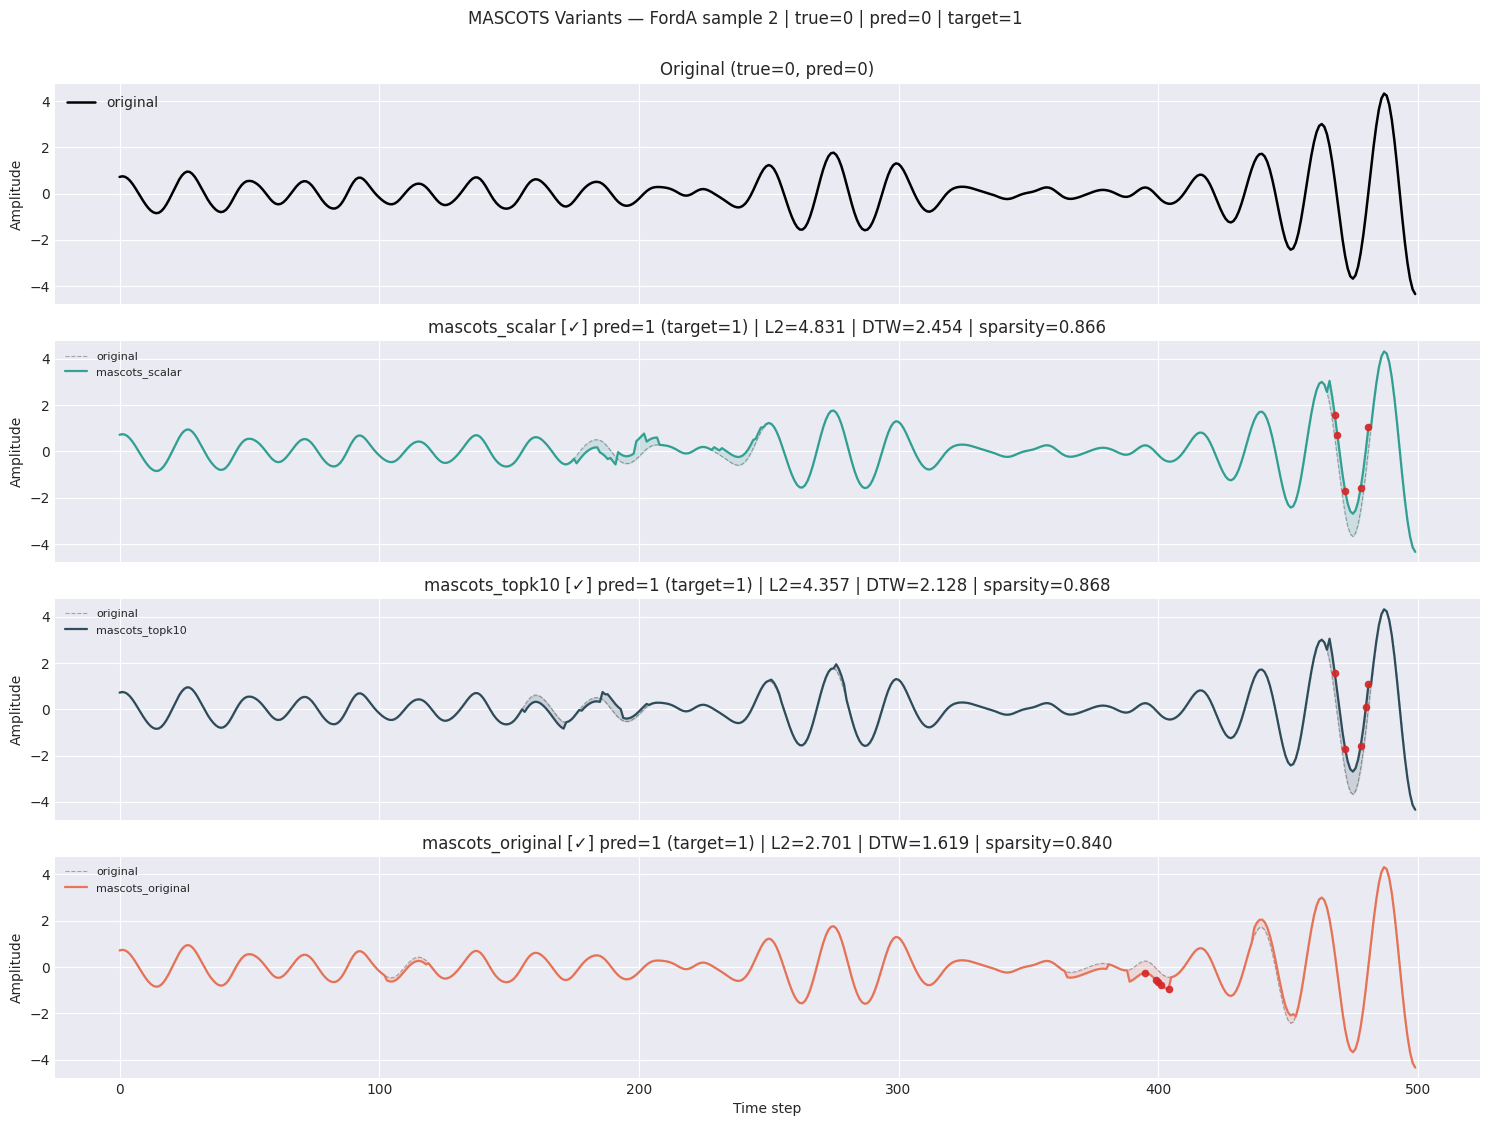

In [14]:
rep = all_cfs[rep_idx]
x_1d = to_channel_first(rep["sample"])[0]
x_axis = np.arange(len(x_1d))

sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred_cf": int(row["pred_cf"]) if pd.notna(row.get("pred_cf")) else None,
        "l2": float(row["l2_norm"]) if pd.notna(row.get("l2_norm")) else np.nan,
        "dtw": float(row["dtw_proximity"]) if pd.notna(row.get("dtw_proximity")) else np.nan,
        "sparsity": float(row["sparsity"]) if pd.notna(row.get("sparsity")) else np.nan,
    }
    for _, row in sample_results.iterrows()
}

orig_row = sample_results.iloc[0]
true_label = int(orig_row["true_label"])
pred_orig = int(orig_row["pred_orig"])
target_class = int(orig_row["target_class"])

n_rows = 1 + len(METHODS)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, 2.8 * n_rows), sharex=True)
fig.suptitle(
    f"MASCOTS Variants — FordA sample {rep_idx} | true={true_label} | pred={pred_orig} | target={target_class}",
    fontsize=12, y=1.001,
)

axes[0].plot(x_1d, color="black", linewidth=1.8, label="original")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig})")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

for i, method_name in enumerate(METHODS, start=1):
    ax = axes[i]
    cf = rep.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred_cf")
    l2_val = info.get("l2", np.nan)
    dtw_val = info.get("dtw", np.nan)
    sp_val = info.get("sparsity", np.nan)

    ax.plot(x_1d, color="black", linewidth=0.8, linestyle="--", alpha=0.3, label="original")
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_1d = to_channel_first(cf)[0]
        ax.plot(cf_1d, linewidth=1.6, alpha=0.95, color=METHOD_COLORS[i - 1], label=method_name)
        ax.fill_between(x_axis, x_1d, cf_1d, color=METHOD_COLORS[i - 1], alpha=0.15)
        diff_abs = np.abs(cf_1d - x_1d)
        top_idx = np.argsort(diff_abs)[-5:]
        ax.scatter(x_axis[top_idx], cf_1d[top_idx], s=20, color="#d62728", alpha=0.9, zorder=4)

    status = "✓" if worked else "✗"
    ax.set_title(
        f"{method_name} [{status}] pred={pred_cf} (target={target_class}) "
        f"| L2={l2_val:.3f} | DTW={dtw_val:.3f} | sparsity={sp_val:.3f}"
    )
    ax.set_ylabel("Amplitude")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

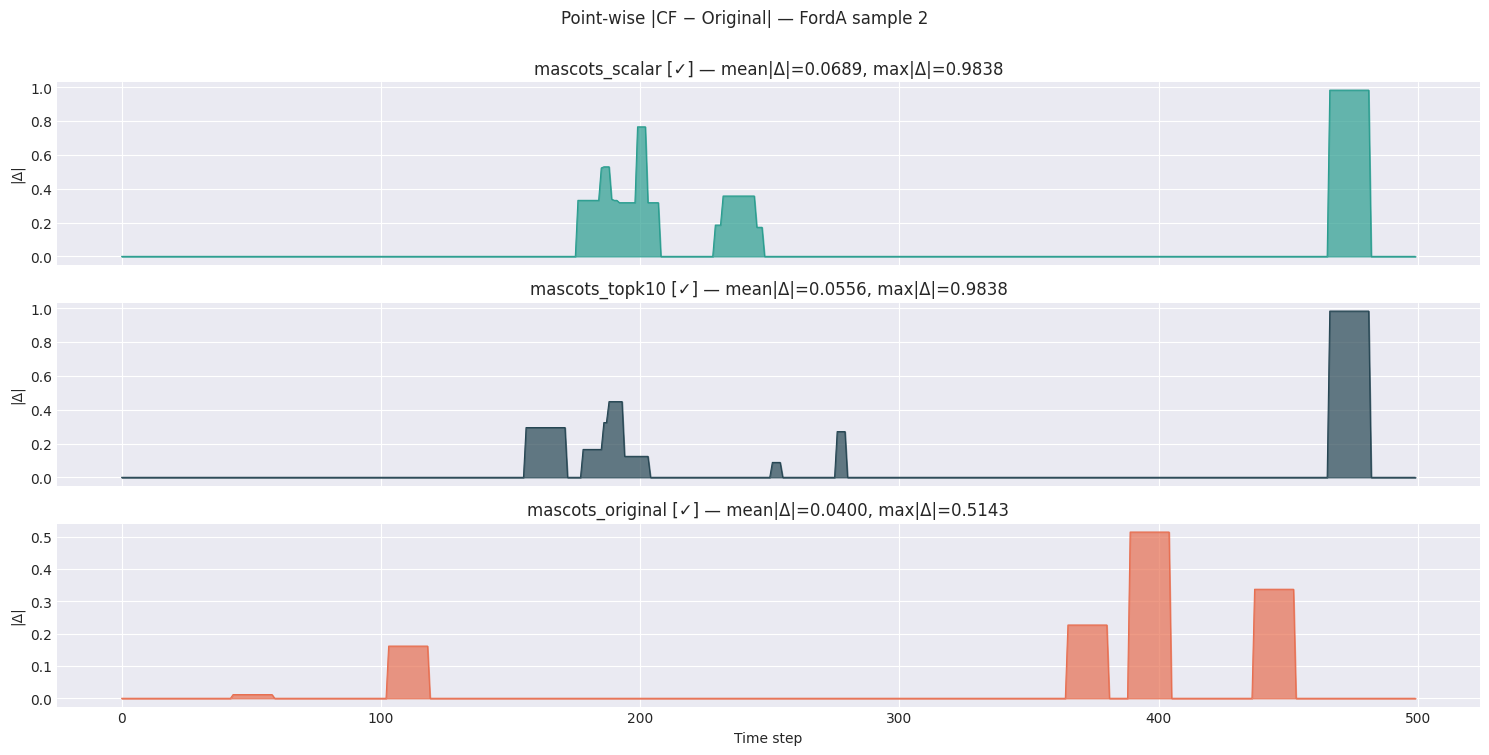

In [15]:
# Point-wise |CF − original| for each method
fig, axes = plt.subplots(len(METHODS), 1, figsize=(15, 2.5 * len(METHODS)), sharex=True)
fig.suptitle(f"Point-wise |CF − Original| — FordA sample {rep_idx}", fontsize=12, y=1.001)

for i, method_name in enumerate(METHODS):
    ax = axes[i]
    cf = rep.get(method_name)
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(method_name)
        continue
    diff = np.abs(to_channel_first(cf)[0] - x_1d)
    info = info_lookup.get(method_name, {})
    status = "✓" if info.get("success", False) else "✗"
    ax.fill_between(x_axis, 0, diff, color=METHOD_COLORS[i], alpha=0.7)
    ax.plot(diff, color=METHOD_COLORS[i], linewidth=0.8)
    ax.set_title(f"{method_name} [{status}] — mean|Δ|={diff.mean():.4f}, max|Δ|={diff.max():.4f}")
    ax.set_ylabel("|Δ|")

axes[-1].set_xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.998])
plt.show()

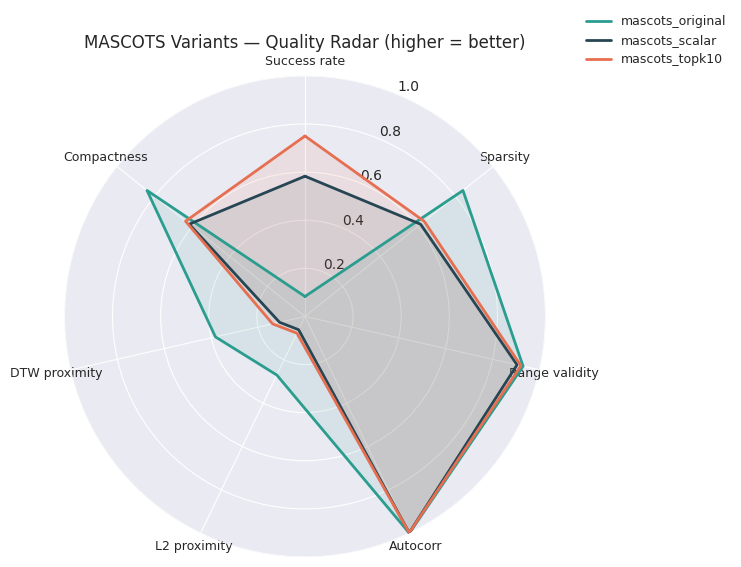

In [16]:
# Radar chart summarising key metrics (all normalised so higher = better)
radar_metrics = [
    "success_rate_norm", "sparsity_mean", "range_validity_mean",
    "autocorr_mean", "l2_score", "dtw_score", "keane_compactness_mean",
]
radar_labels = [
    "Success rate", "Sparsity", "Range validity",
    "Autocorr", "L2 proximity", "DTW proximity", "Compactness",
]

plot_df2 = plot_df.copy()
plot_df2["success_rate_norm"] = plot_df2["success_rate"] / 100.0
plot_df2["l2_score"] = 1.0 / (1.0 + plot_df2["l2_norm_mean"].fillna(np.inf))
plot_df2["dtw_score"] = 1.0 / (1.0 + plot_df2["dtw_proximity_mean"].fillna(np.inf))

N_ax = len(radar_metrics)
angles = [n / float(N_ax) * 2 * np.pi for n in range(N_ax)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=9)
ax.set_ylim(0, 1)

for row_i, row in plot_df2.iterrows():
    vals = [float(row.get(m, 0) or 0) for m in radar_metrics]
    vals += vals[:1]
    color = METHOD_COLORS[row_i % len(METHOD_COLORS)]
    ax.plot(angles, vals, linewidth=2, linestyle="solid", label=row["method"], color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_title("MASCOTS Variants — Quality Radar (higher = better)", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

## Context: paper-reported numbers (not directly comparable)

The MASCOTS paper (Table 2, univariate benchmark: TwoLeadECG, GunPoint, Earthquakes, Coffee, Wine, ItalyPowerDemand — **not FordA**) reports, averaged across datasets, mean ± std:

| Method | Validity | Proximity (↓) | Sparsity | Plausibility |
|---|---|---|---|---|
| MASCOTS (λ=C=0.1) | 0.44 ± 0.18 | 0.24 ± 0.18 | **0.71 ± 0.12** | 0.98 ± 0.02 |
| MASCOTS (λ=C=0.0) | 0.44 ± 0.21 | 0.35 ± 0.25 | 0.65 ± 0.15 | 0.84 ± 0.29 |
| M-CELS | 0.11 ± 0.08 | **0.08 ± 0.10** | 0.49 ± 0.00 | 0.99 ± 0.01 |
| Glacier | 0.41 ± 0.23 | 2.32 ± 2.34 | 0.00 ± 0.00 | **1.00 ± 0.00** |

Headline claims: MASCOTS' main advantage over M-CELS/Glacier is **sparsity** (far fewer points changed) at comparable validity to Glacier, trading off some proximity against M-CELS. The paper's own hyperparameters were `max_borf_changes=20` and `C (λ) ∈ {0.0, 0.1}` with a SHAP surrogate attribution — which is what `mascots_original` above is configured with (`ORIGINAL_MAX_BORF_CHANGES = 20`, `C=0.1`).

Since FordA/SimpleCNN is a different dataset/model than the paper's benchmark, don't read the summary table above as reproducing Table 2 — it only tells us whether **our vendored port and the authors' own code agree** on the same task. If `mascots_scalar`/`mascots_topk10` and `mascots_original` land in a similar validity/sparsity/proximity ballpark here, that's evidence the reimplementation is faithful; large, systematic gaps would flag a divergence worth investigating in `cfts/cf_mascots/_borf_explainer.py`.

In [17]:
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.
